## Execution Time of Single Conversion Code in Knowledge Graph

In [1]:
from datetime import datetime

print(f"Current date: {datetime.now().date()}")

Current date: 2025-01-27


In [2]:
%pip install py-cpuinfo -q
%pip install gputil -q

import cpuinfo
import GPUtil

cpu_name = cpuinfo.get_cpu_info()['brand_raw']
print(f"CPU: {cpu_name}")

gpus = GPUtil.getGPUs()
print(f"GPU:0: {GPUtil.getGPUs()[0].name}")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
CPU: Intel(R) Core(TM) i7-7700K CPU @ 4.20GHz
GPU:0: NVIDIA GeForce GTX 1080 Ti


In [3]:
from pathlib import Path
import sys
import os

parent_directory = Path.cwd().parent
sys.path.insert(0, str(parent_directory))
src_directory = os.path.join(parent_directory, "src")
sys.path.insert(0, src_directory)

In [4]:
import matplotlib.pyplot as plt
import numpy as np


def histogram(data, title, bins=5):
    bin_edges = np.linspace(0, max(data), bins + 1)
    n, bins, patches = plt.hist(data, bins=bin_edges, alpha=0.7)
    for patch in patches:
        height = patch.get_height()
        plt.annotate(f'{int(height)}',
                     (patch.get_x() + patch.get_width() / 2, height),
                     textcoords="offset points",
                     xytext=(0,5),
                     ha='center')
    plt.title(title)
    plt.xlabel('Execution Time (s)')
    plt.xticks(bin_edges)
    plt.ylabel('Number')
    plt.show()

2025-01-27 15:44:33.329871: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-27 15:44:34.299001: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-01-27 15:44:38.019688: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-27 15:44:38.019927: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required li

Execution time: 1.449952833354473e-07 to 0.0016289816005155445 for image size (128, 128).


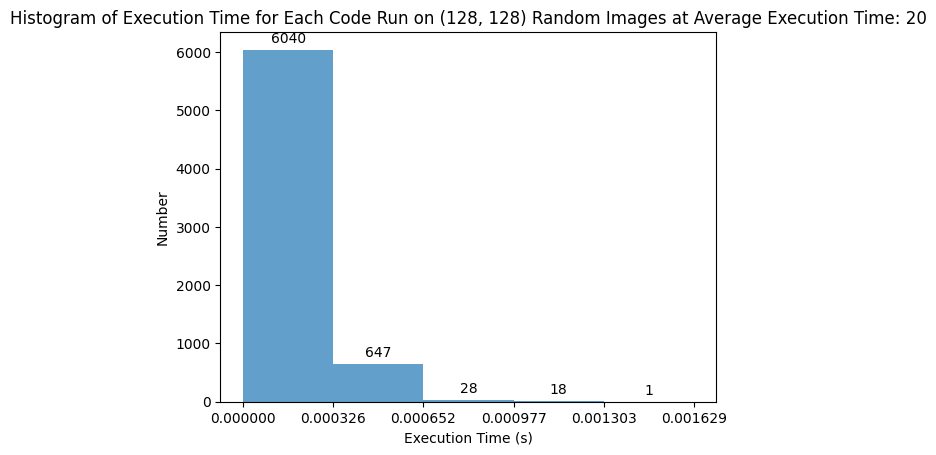

Execution time: 1.4500110410153865e-07 to 0.0044909815012943 for image size (256, 256).


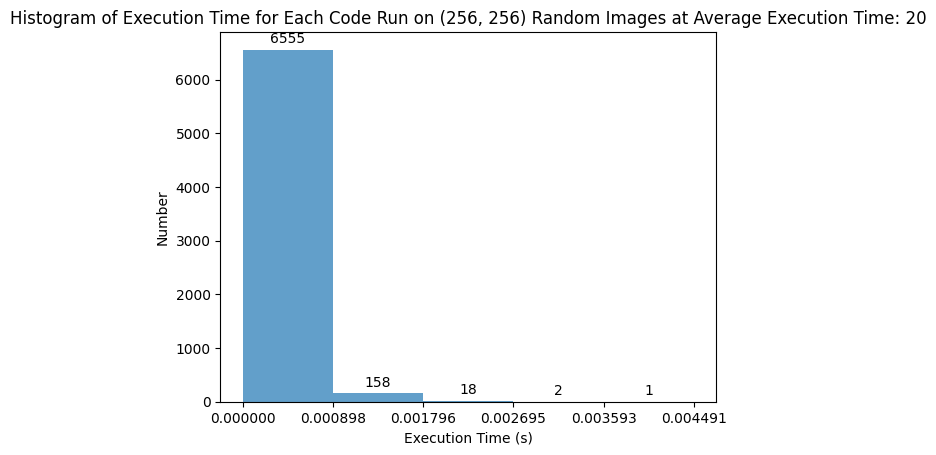

Execution time: 1.4500110410153865e-07 to 0.012887635501101613 for image size (512, 512).


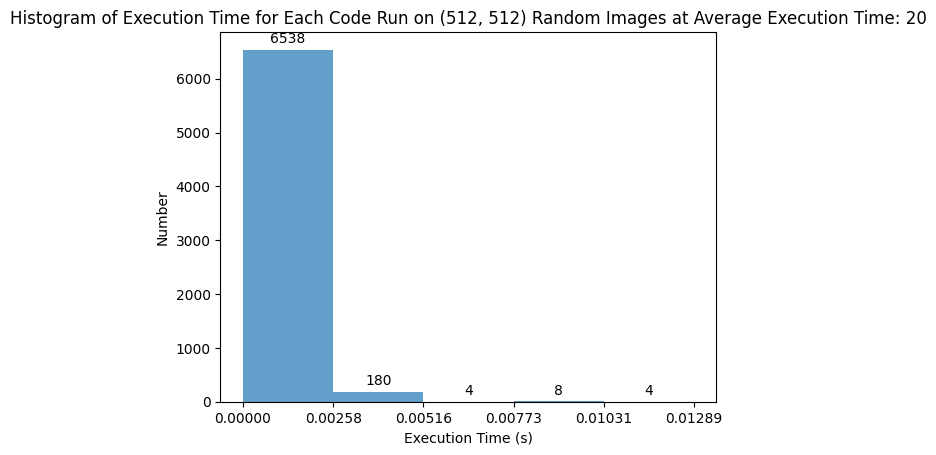

Execution time: 1.6000121831893922e-07 to 0.04500945964828133 for image size (1024, 1024).


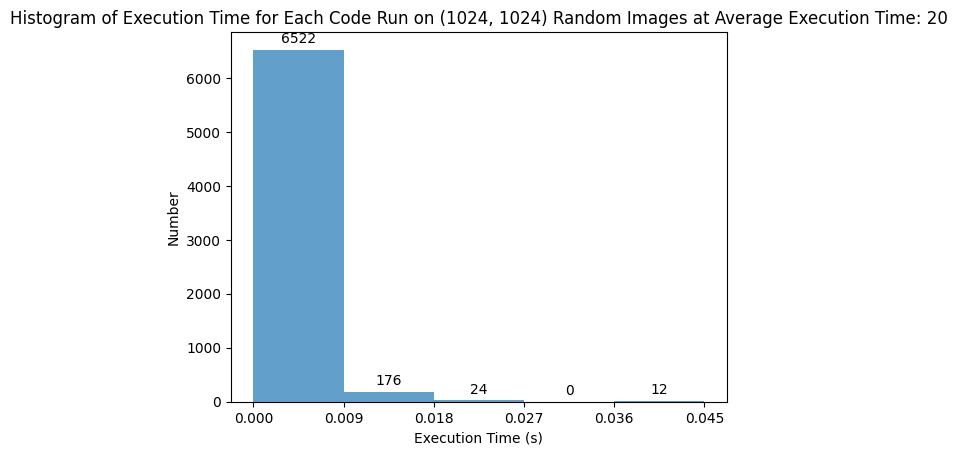

Execution time: 1.7999554984271527e-07 to 0.17483013350283727 for image size (2048, 2048).


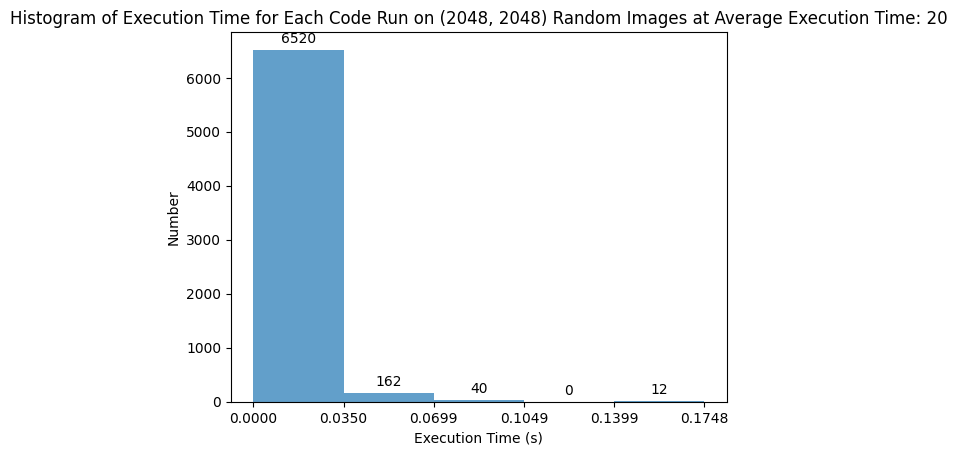

In [5]:
from src.im2im import _constructor
from tests.time_cost_measure import time_cost_in_kg

kg = _constructor.knowledge_graph

repeat_count = 20
for img_size in [(128, 128), (256, 256), (512, 512), (1024, 1024), (2048, 2048)]:
    time_costs = time_cost_in_kg(kg, img_size, repeat_count)
    
    print(f"Execution time: {min(time_costs.values())} to {max(time_costs.values())} for image size {img_size}.")
    histogram(time_costs.values(), f"Histogram of Execution Time for Each Code Run on {img_size} Random Images at Average Execution Time: {repeat_count}")